In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import time
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print (tf.__version__)


2.19.0


In [9]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## DELIVERABLE 1: DATA LOADING AND PREPROCESSING

## LOAD CSV FILES

In [10]:
train = pd.read_csv("/content/drive/MyDrive/M6_assignment/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/M6_assignment/sign_mnist_test.csv")

print(train.shape)
print(test.shape)

(27455, 785)
(7172, 785)


## NORMALISE PIXEL VALUES TO [0, 1]

In [11]:
# seperate pixel values from labels
x_train_full = train.drop('label', axis = 1).values
y_train_full = train['label'].values
x_test = test.drop('label', axis = 1).values
y_test = test['label'].values

x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

# reshaping into 28x28x1tensors for Conv2D
x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

num_classes = 25
class_names = [chr (i) for i in range (65,91) if chr(i) not in ('J', 'Z')]

## CREATE A VALIDATION SPLIT FROM THE TRAINING SET

In [12]:
# splitting 20% of the data for validation
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_full, y_train_full,
    test_size = 0.2, random_state = 42, stratify = y_train_full)

y_train = to_categorical(y_train, num_classes)
y_valid = to_categorical(y_valid, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f"Train: {x_train.shape[0]} | valid: {x_valid.shape[0]} | test: {x_test.shape[0]}")
print("Classes:", class_names)

Train: 21964 | valid: 5491 | test: 7172
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


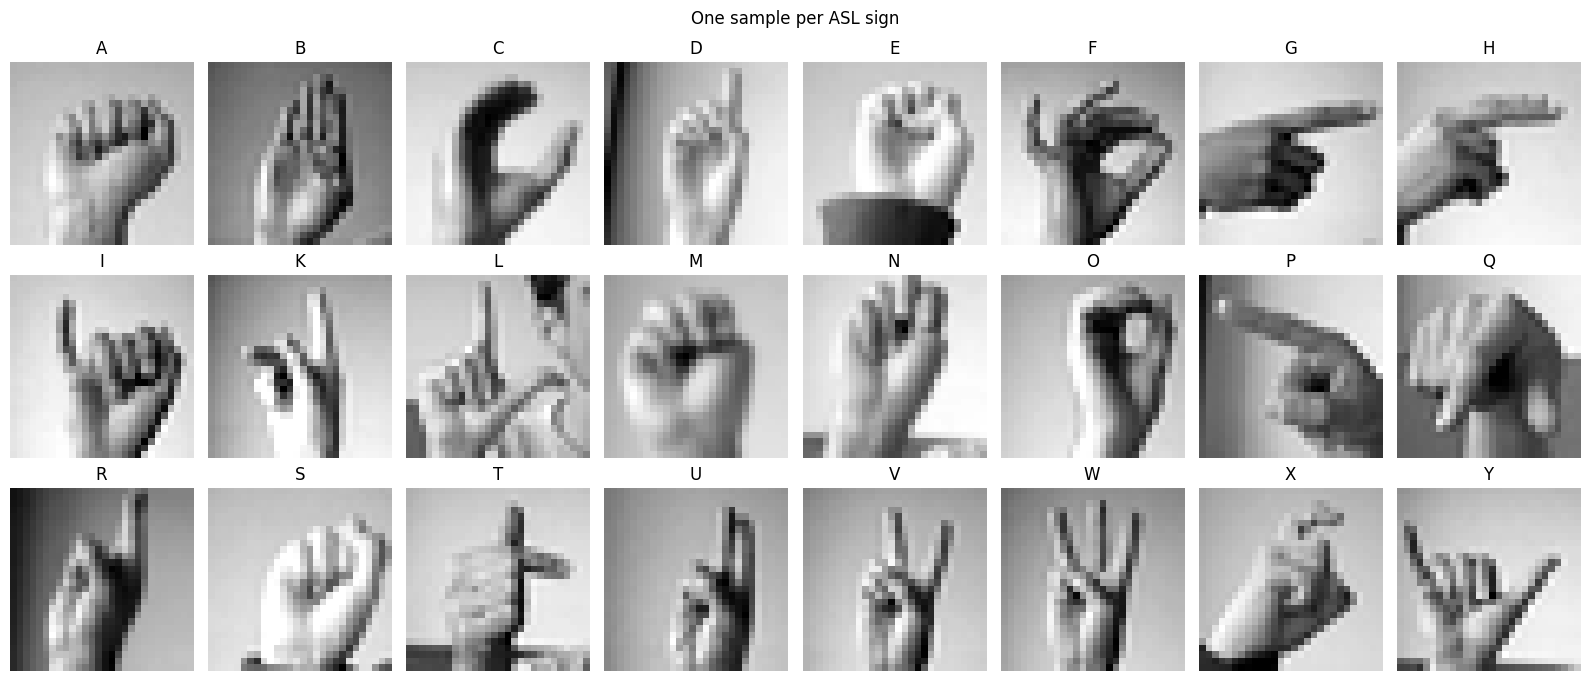

In [13]:
unique_labels = np.unique(y_train.argmax(axis = 1))

fig, axes = plt.subplots(3, 8, figsize = (16, 7))
axes = axes.flatten()

# plotting one simple image per class
for i, class_name_char in enumerate(class_names):
  actual_label_value = i
  if i >= 9: # Account for the skipped 'J' (label 9)
    actual_label_value += 1

  sample = np.where(y_train.argmax(axis = 1) == actual_label_value)[0][0]
  axes[i].imshow(x_train[sample].squeeze(), cmap = 'gray')
  axes[i].set_title(class_name_char)
  axes[i].axis('off')

plt.suptitle("One sample per ASL sign")
plt.tight_layout()
plt.show()

## DELIVERABLE 2: CNN ARCHITECTURES

## BASELINE CNN

In [14]:
model_baseline = models.Sequential([
    keras.Input(shape = (28, 28,1)),
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation = 'softmax')
])

model_baseline.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model_baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,577 (1.62 MB)

 Trainable params: 423,577 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

## ENHANCED VGG-STYLE CNN

In [15]:
model_enhanced = models.Sequential([
    keras.Input(shape = (28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation = 'softmax'),

])

model_enhanced.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 327,673 (1.25 MB)

 Trainable params: 326,777 (1.25 MB)

 Non-trainable params: 896 (3.50 KB)

## DELIVERABLE 3: TRAINING, TESTING AND EVALUATION

## HYPERPARAMETER TUNING -- BASELINE CNN

In [16]:
callbacks = [
    EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

start = time.time()

# trianing the baseline model for upto 30 epochs with early stopping
history_baseline = model_baseline.fit(
    x_train, y_train,
    validation_data = (x_valid, y_valid),
    epochs = 30,
    batch_size = 64,
    callbacks = callbacks,
    verbose = 1
)

baseline_time = round(time.time() - start)
print(f"Training time: {baseline_time} seconds")

Epoch 1/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4121 - loss: 1.8984 - val_accuracy: 0.8638 - val_loss: 0.5423 - learning_rate: 0.0010
Epoch 2/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7561 - loss: 0.7231 - val_accuracy: 0.9741 - val_loss: 0.1676 - learning_rate: 0.0010
Epoch 3/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8569 - loss: 0.4126 - val_accuracy: 0.9942 - val_loss: 0.0724 - learning_rate: 0.0010
Epoch 4/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8924 - loss: 0.3065 - val_accuracy: 0.9984 - val_loss: 0.0346 - learning_rate: 0.0010
Epoch 5/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9205 - loss: 0.2250 - val_accuracy: 0.9998 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 6/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9344 - loss: 0.1825 - val_accuracy: 0.9998 - val_loss: 0.0102 - learning_rate: 0.0010
Epoch 7/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9435 - loss: 0.1575 

## HYPERPARAMETER TUNING -- ENHANCED CNN

In [17]:
# fresh call backs to avoid the results rom previous training runs
fresh_callbacks = [
    EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

model_enhanced.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

start = time.time()

# training the enhanced model for upto 30 epochs with ealry stopping
history_enhanced = model_enhanced.fit(
    x_train, y_train,
    validation_data = (x_valid, y_valid),
    epochs = 30,
    batch_size = 64,
    callbacks = fresh_callbacks,
    verbose = 1
)

enhanced_time = round(time.time() - start)
print(f"Training time: {enhanced_time} seconds")


Epoch 1/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.6792 - loss: 1.0193 - val_accuracy: 0.0973 - val_loss: 4.0642 - learning_rate: 0.0010
Epoch 2/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9817 - loss: 0.0629 - val_accuracy: 0.9960 - val_loss: 0.0197 - learning_rate: 0.0010
Epoch 3/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9894 - loss: 0.0354 - val_accuracy: 0.9707 - val_loss: 0.0973 - learning_rate: 0.0010
Epoch 4/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9929 - loss: 0.0260 - val_accuracy: 1.0000 - val_loss: 2.2095e-04 - learning_rate: 0.0010
Epoch 5/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9970 - loss: 0.0111 - val_accuracy: 0.9995 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 6/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9931 - loss: 0.0231 - val_accuracy: 1.0000 - val_loss: 4.5226e-04 - learning_rate: 0.0010
Epoch 7/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9973 - loss:

##  TRAINING VS VALIDATION - ACCURACY AND LOSS COMPARISON



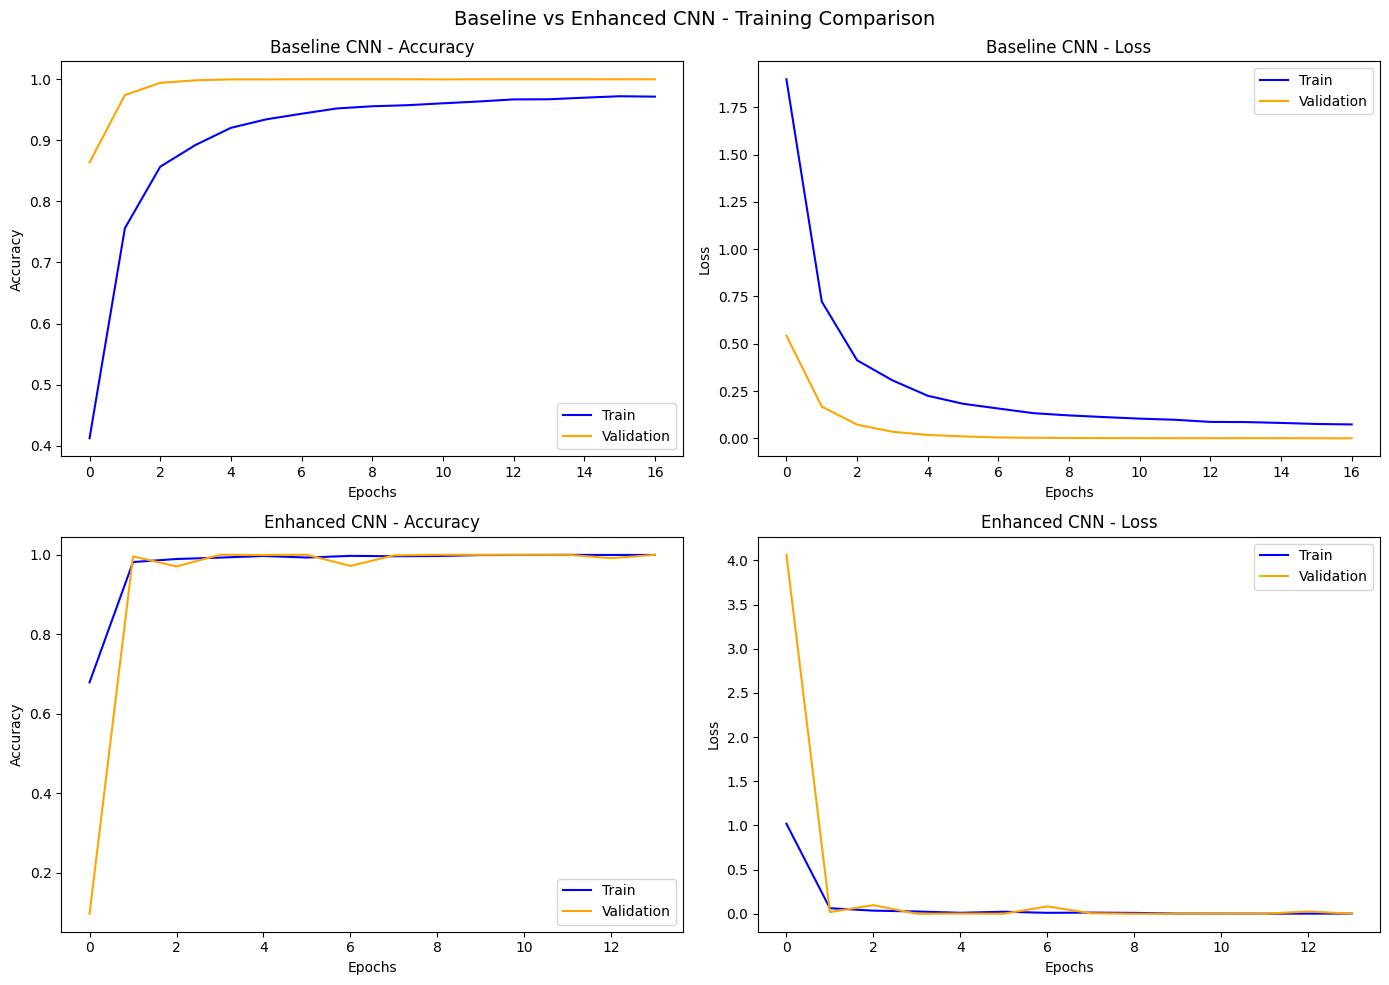

In [18]:
# training and validation accuracy and loss graphs for both the models
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

axes[0, 0].plot(history_baseline.history['accuracy'], label = 'Train', color = 'blue')
axes[0, 0].plot(history_baseline.history['val_accuracy'], label = 'Validation', color = 'orange')
axes[0, 0].set_title('Baseline CNN - Accuracy')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

axes[0, 1].plot(history_baseline.history['loss'], label = 'Train', color = 'blue')
axes[0, 1].plot(history_baseline.history['val_loss'], label = 'Validation', color = 'orange')
axes[0, 1].set_title('Baseline CNN - Loss')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

axes[1, 0].plot(history_enhanced.history['accuracy'], label = 'Train', color = 'blue')
axes[1, 0].plot(history_enhanced.history['val_accuracy'], label = 'Validation', color = 'orange')
axes[1, 0].set_title('Enhanced CNN - Accuracy')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()

axes[1, 1].plot(history_enhanced.history['loss'], label = 'Train', color = 'blue')
axes[1, 1].plot(history_enhanced.history['val_loss'], label = 'Validation', color = 'orange')
axes[1, 1].set_title('Enhanced CNN - Loss')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()

plt.suptitle("Baseline vs Enhanced CNN - Training Comparison", fontsize = 14)
plt.tight_layout()
plt.show()

## MODEL COMPARISON - ACCURACY, LOSS, PARAMETERS AND TRAINING TIME

In [19]:
# comparing the perfromance of both the models
baseline_loss, baseline_accuracy = model_baseline.evaluate(x_test, y_test, verbose = 0)
enhanced_loss, enhanced_accuracy = model_enhanced.evaluate(x_test, y_test, verbose = 0)

print("Model comparision on test set")
print("==============================")
print(f"Baseline - Accuracy: {baseline_accuracy*100:.2f} | Loss: {baseline_loss:.4f}")
print(f"Enhanced - Accuracy: {enhanced_accuracy*100:.2f} | Loss: {enhanced_loss:.4f}")
print(f"Baseline - Params: {model_baseline.count_params():,}")
print(f"Enhanced - Params: {model_enhanced.count_params():,}")
print(f"Baseline - Epochs: {len(history_baseline.history['accuracy'])}")
print(f"Enhanced - Epochs: {len(history_enhanced.history['accuracy'])}")
print(f"Baseline - Time: {baseline_time} seconds")
print(f"Enhanced - Time: {enhanced_time} seconds")

Model comparision on test set
Baseline - Accuracy: 92.48 | Loss: 0.2347
Enhanced - Accuracy: 99.62 | Loss: 0.0090
Baseline - Params: 423,577
Enhanced - Params: 327,673
Baseline - Epochs: 17
Enhanced - Epochs: 14
Baseline - Time: 38 seconds
Enhanced - Time: 65 seconds


## 3.3 CONFUSION MATRIX - BASELINE vs ENHANCED CNN

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


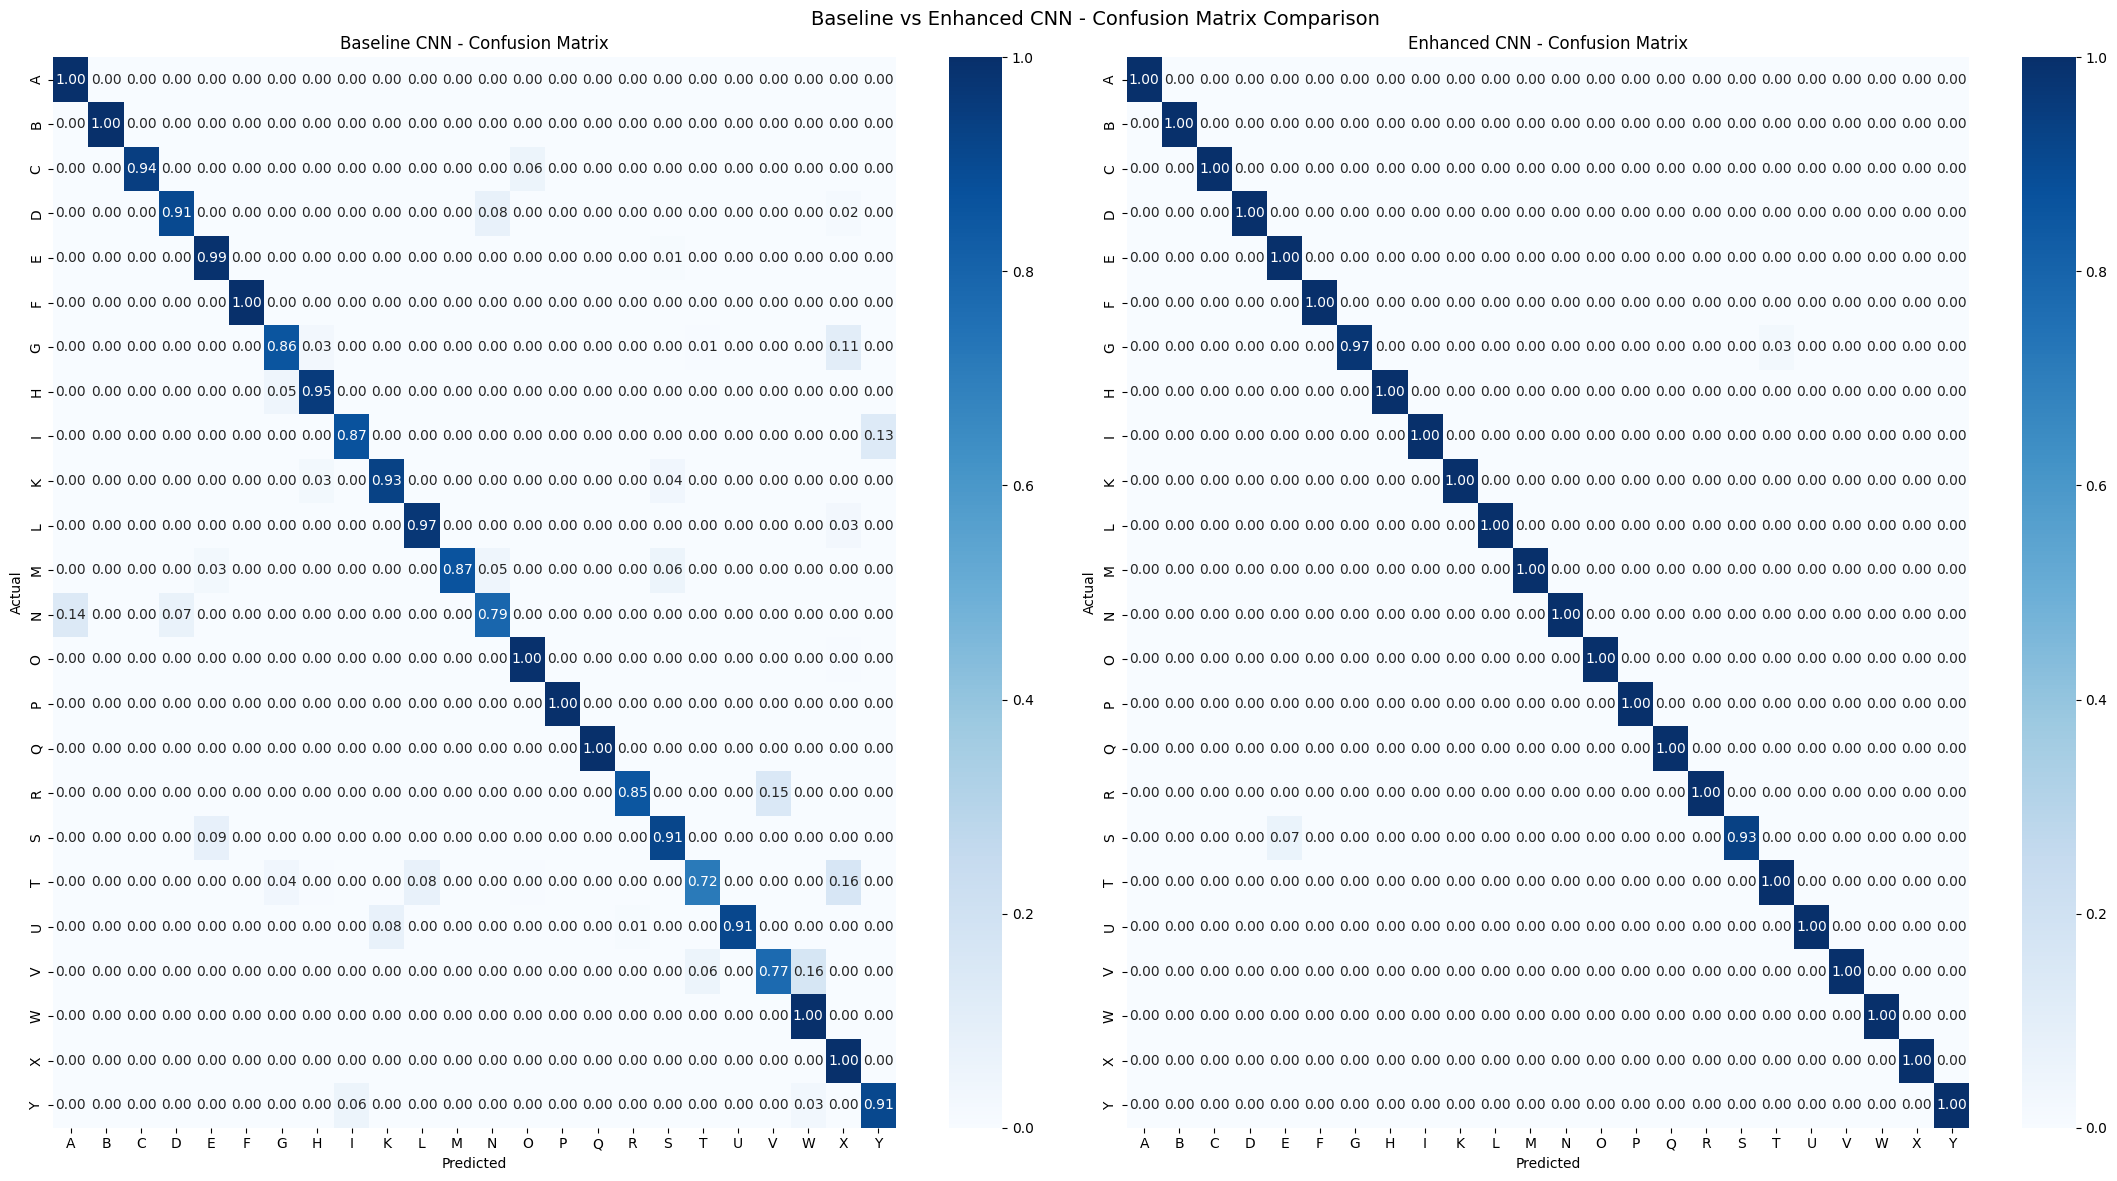

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (22, 12))

# confusion matrix for the baseline model
y_test_classes = np.argmax(y_test, axis = 1)
y_pred_baseline = model_baseline.predict(x_test)
y_pred_baseline_classes = np.argmax(y_pred_baseline, axis = 1)
cm_baseline = confusion_matrix(y_test_classes, y_pred_baseline_classes)
cm_baseline_normalized = cm_baseline.astype('float') / cm_baseline.sum(axis = 1)[:, np.newaxis]
sns.heatmap(cm_baseline_normalized, annot = True, fmt = '.2f', cmap = 'Blues',
            xticklabels = class_names, yticklabels = class_names, ax = ax1)
ax1.set_title('Baseline CNN - Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# confusion matrix for the enhanced model
y_pred_enhanced = model_enhanced.predict(x_test)
y_pred_classes = np.argmax(y_pred_enhanced, axis = 1)
cm_enhanced = confusion_matrix(y_test_classes, y_pred_classes)
cm_enhanced_normalized = cm_enhanced.astype('float') / cm_enhanced.sum(axis = 1)[:, np.newaxis]
sns.heatmap(cm_enhanced_normalized, annot = True, fmt = '.2f', cmap = 'Blues',
            xticklabels = class_names, yticklabels = class_names, ax = ax2)
ax2.set_title('Enhanced CNN - Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.suptitle("Baseline vs Enhanced CNN - Confusion Matrix Comparison", fontsize = 14)
plt.tight_layout()
plt.show()

## CLASSIFICATION REPORT - PRECISION, RECALL AND F1-SCORE

In [21]:
print("Classification Report - Baseline CNN")
print("="*50)
y_pred_baseline = model_baseline.predict(x_test)
y_pred_baseline_classes = np.argmax(y_pred_baseline, axis = 1)
print(classification_report(y_test_classes, y_pred_baseline_classes, target_names = class_names))

print ("Classification Report - Enhanced CNN")
print("="*50)
print(classification_report(y_test_classes, y_pred_classes, target_names = class_names))

Classification Report - Baseline CNN
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           A       0.89      1.00      0.94       331
           B       1.00      1.00      1.00       432
           C       1.00      0.94      0.97       310
           D       0.91      0.91      0.91       245
           E       0.94      0.99      0.97       498
           F       1.00      1.00      1.00       247
           G       0.91      0.86      0.88       348
           H       0.95      0.95      0.95       436
           I       0.93      0.87      0.90       288
           K       0.94      0.93      0.94       331
           L       0.91      0.97      0.94       209
           M       1.00      0.87      0.93       394
           N       0.86      0.79      0.82       291
           O       0.93      1.00      0.96       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
   

## SAMPLE PREDICTIONS

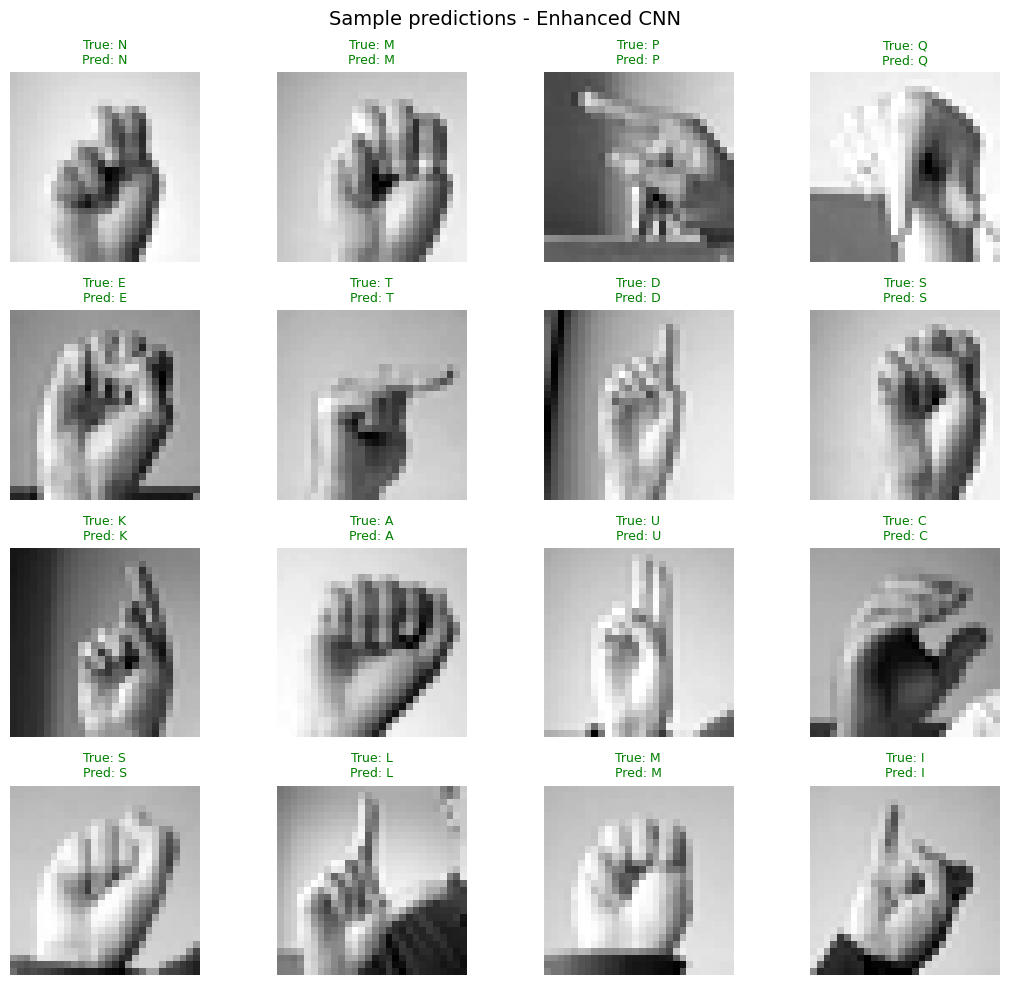

In [22]:
fig, axes = plt.subplots(4, 4, figsize = (11,10))
axes = axes.flatten()

indices = np.random.choice(len(x_test), 16, replace = False)

for i, idx in enumerate(indices):
  axes[i].imshow(x_test[idx].squeeze(), cmap = 'gray')

  true_label_numeric = y_test_classes[idx]
  pred_label_numeric = y_pred_classes[idx]
  true_label_mapped_idx = true_label_numeric

  if true_label_numeric > 8:
    true_label_mapped_idx -= 1

  pred_label_mapped_idx = pred_label_numeric
  if pred_label_numeric > 8:
    pred_label_mapped_idx -= 1

  true_label = class_names[true_label_mapped_idx]
  pred_label = class_names[pred_label_mapped_idx]

  color = 'green' if true_label == pred_label else 'red'
  axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color = color, fontsize = 9)
  axes[i].axis('off')

plt.suptitle("Sample predictions - Enhanced CNN", fontsize = 14)
plt.tight_layout()
plt.show()